<a href="https://colab.research.google.com/github/kabirmuwal/Academic-Projects/blob/main/Uber_Fare_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UBER FARE PREDICTOR**

*Uber has been one of the most known cab service provider throughout the world. In the Model, We will be identifying the best fares to be offered. That will help Uber and it's clients to have a better bond and will help the firm to grow even more. We will be using different Machine learning models to check the accuracy of the data we have till now after all Money is important and accuracy for the same is essential for a business to grow.*



**Reference for the Dataset:** https://www.kaggle.com/code/yasserh/uber-fare-prediction-comparing-best-ml-models/notebook

### **IMPORTANT LIBRARIES**

In [ ]:
import pandas as pnds
import numpy as npy
import matplotlib.pyplot as matply
import seaborn as sbrn
import folium
import branca.colormap as clrmp
from folium.plugins import HeatMap
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

**The remaining Libraries I will be using when they will be required in the procedure**

 **1. Data Exploration** : *Let's see what are the different parameters that we can is the referred data set*

In [ ]:
# Let's see what information can we gather with the refrence provided

df_Ubr = pnds.read_csv("/content/uber.csv")
print (df_Ubr.shape)
df_Ubr.head()

(200000, 9)


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


**As we can see the data set includes the columns as follows:**



1.   **Unnamed: 0:** It corresponds to serial number for every ride
2.   **key:** It corresponds the passenger started the journey
3.   **Fare amount:** Estimation of price in accordance with pickup location and dropoff location
4.   **Pick up date amd time:** It corresponds to the date and time on which the ride was booked
5.   **Pick up latitude:**It corresponds to the latitude of the location from where the journey starts
6.   **Pick up Longitude:** It corresponds to the longitude of the location from where the journey of the passenger has started
7.   **Drop off latitude:** It corresponds to the latitude of the location where the journey ended
8.   **Drop off longitude:** It corresponds to the longitude of the location where the journey has ended
9.   **Passenger count:** It reflects for how many passengers the ride was booked

### **2. Exploratory Data Analysis (EDA):** We will check and clean the data as per requirement. We need to analyse the pickup and dropoff location with respect to passengers and the amount that has been assigned for the complete ride.

In [ ]:
df_main = df_Ubr.copy()
if df_Ubr.isna().sum().sum() == 0:
  print ("Missing values not found in DataSet")
else:
    print ("Missing values found in DataSet")

Missing values found in DataSet


😞 Data is not Clean, let's see how many NaN values are there and what best can be done with it.

In [ ]:
# removing columns that are not required

to_drop = ['key']

df_main.drop(to_drop, inplace=True, axis=1)

In [ ]:
# removing columns that are not required
to_drop = ['Unnamed: 0']

df_main.drop(to_drop, inplace=True, axis=1)


In [ ]:
# checking if the data set has any NaN values
df_main.isna().sum()

,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


In [ ]:
df_main.dropna(inplace=True)

The referred data set is clean now 🙂

In [ ]:
# Checking if the data set still has some NaN values or not
df_main.isna().sum()

,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


In [ ]:
# Summary statiscs for Numeric Variables

df_main.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000,199999.000000
mean,11.359892,-72.527631,39.935881,-72.525292,39.923890,1.684543
std,9.901760,11.437815,7.720558,13.117408,6.794829,1.385995
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [ ]:
# Summary statiscs for object Variables

df_main.describe(include='object')

,pickup_datetime
count,199999
unique,196628
top,2014-04-13 18:19:00 UTC
freq,4


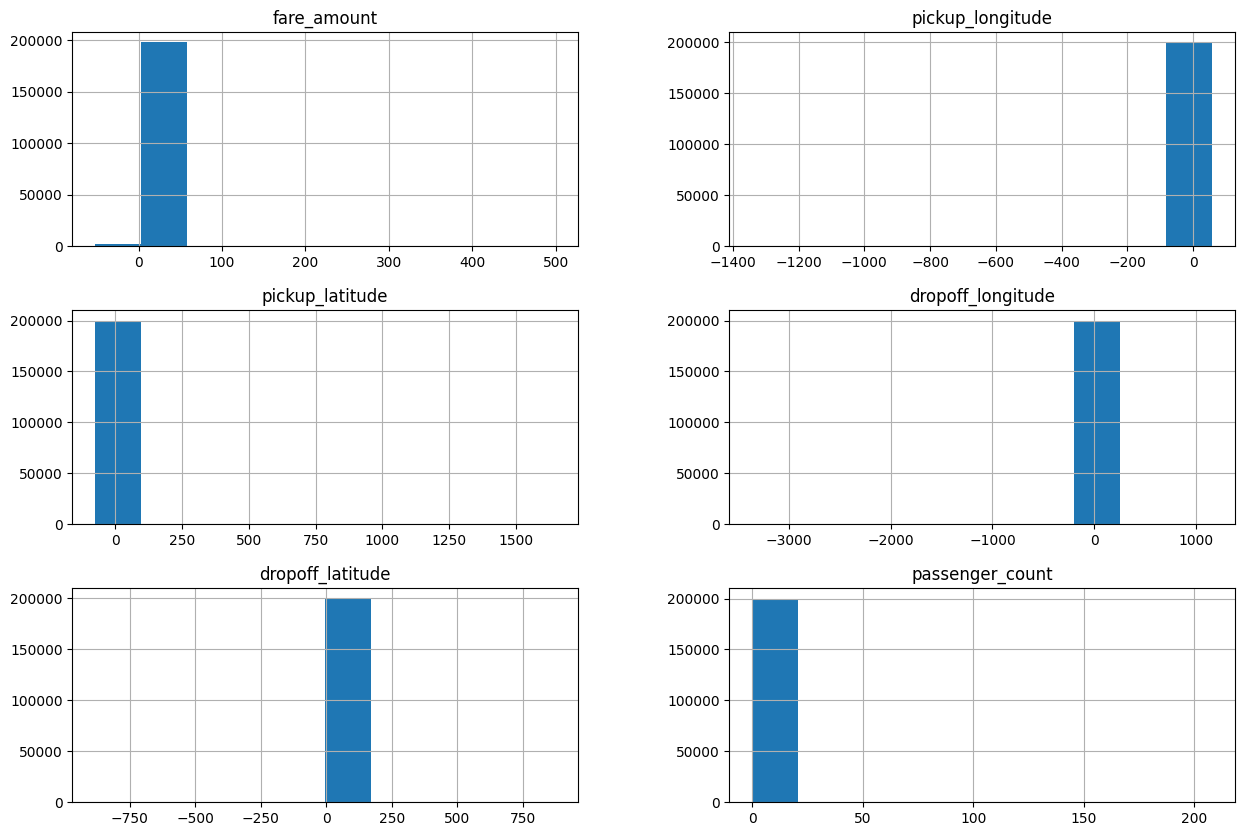

In [ ]:
#Histogram for the referred Dataset

df_main.hist(figsize=(15,10))
matply.show()


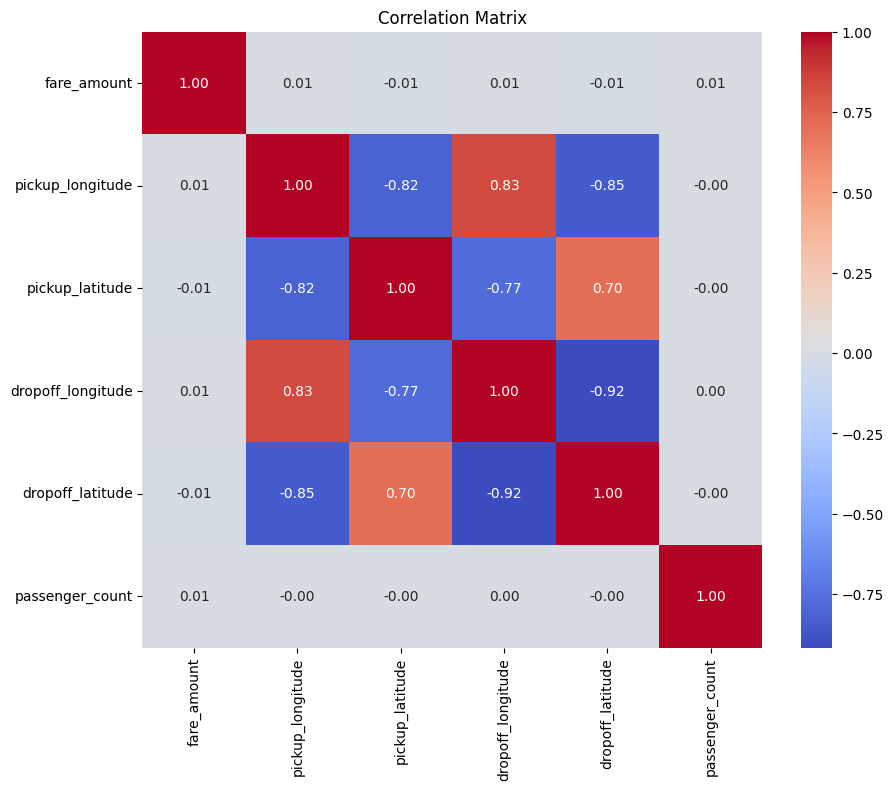

In [ ]:
# Correlation Matrix for the referred Dataset

matply.figure(figsize=(10,8))
sbrn.heatmap(df_main.select_dtypes(include=['float64','int64']).corr(), annot=True, fmt='.2f', cmap='coolwarm')
matply.title("Correlation Matrix")
matply.show()

## **3. Feature Engineering / Data pre-processing**

In [ ]:
df_main.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [ ]:
df_fin=df_main.copy()

In [ ]:
df_fin.head(2)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1


In [ ]:
!pip install --upgrade pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 16.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.1.4
    Uninstalling pandas-2.1.4:
      Successfully uninstalled pandas-2.1.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pandas<2.2.2dev0,>=2.0, but you have pandas 2.2.3 which is incompatible.
google-colab 1.0.0 requires pandas==2.1.4, but you have pandas 2.2.3 which is incompatible.


In [ ]:
# Separting Date time column into Date and Time Column
# df_fin=df_main.copy()
df_fin['pickup_datetime'] = pnds.to_datetime(df_fin['pickup_datetime']).tolist()
# df_fin['pickup_date'] = pnds.to_datetime(df_fin['pickup_datetime']).dt.date
df_fin['year'] = df_fin['pickup_datetime'].dt.year
df_fin['month'] = df_fin['pickup_datetime'].dt.month
df_fin['day'] = df_fin['pickup_datetime'].dt.day
df_fin['dayofweek'] = df_fin['pickup_datetime'].dt.dayofweek
df_fin['quarter'] = df_fin['pickup_datetime'].dt.quarter

df_fin['hour'] = df_fin['pickup_datetime'].dt.hour
df_fin['minutes'] = df_fin['pickup_datetime'].dt.minute
df_fin['seconds'] = df_fin['pickup_datetime'].dt.second
# df_fin['pickup_time'] = pnds.to_datetime(df_fin['pickup_datetime']).dt.time
df_fin['isweekend'] = df_fin['dayofweek'].apply(lambda x:1 if x>=5 else 0)
df_fin['ismonthstart'] = df_fin['pickup_datetime'].dt.is_month_start.astype(int)
df_fin['ismonthend'] = df_fin['pickup_datetime'].dt.is_month_end.astype(int)

df_fin['weekyear'] = df_fin['pickup_datetime'].dt.isocalendar().week

df_fin['day_elapse'] = (df_fin['pickup_datetime'] - df_fin['pickup_datetime'].min()).dt.days
df_fin['seconds_elapse'] = (df_fin['pickup_datetime'] - df_fin['pickup_datetime'].min()).dt.total_seconds()

df_fin.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,...,quarter,hour,minutes,seconds,isweekend,ismonthstart,ismonthend,weekyear,day_elapse,seconds_elapse
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,...,2,19,52,6,0,0,0,19,2317,200255804.0
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,...,3,20,4,56,0,0,0,29,197,17088574.0
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,...,3,21,45,0,0,0,0,35,235,20377778.0
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,...,2,8,22,21,0,0,0,26,176,15232019.0
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,...,3,17,47,0,0,0,0,35,2065,178475498.0


In [ ]:
# removing columns with Nan values and are unwanted
to_drop = ['pickup_datetime']

df_fin.drop(to_drop, inplace=True, axis=1)


In [ ]:
#Checking for types of data for different Variables

df_fin.dtypes


,0
fare_amount,float64
pickup_longitude,float64
pickup_latitude,float64
dropoff_longitude,float64
dropoff_latitude,float64
passenger_count,int64
year,int32
month,int32
day,int32
dayofweek,int32


Split datasets

In [ ]:
# Separate features and target variable
X = df_fin.drop(columns=['fare_amount'])  # Features
y = df_fin['fare_amount']                  # Target

In [ ]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define models
models = {
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "Linear Regression": LinearRegression(),
    "Lasso Regression": Lasso(alpha=0.1),  # Adjust alpha if needed
}

# Train and evaluate regression models
results = {}
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    results[model_name] = mse
    print(f"{model_name} Mean Squared Error: {mse:.2f}")

# Identify the best model
best_model_name = min(results, key=results.get)
best_model_mse = results[best_model_name]

print(f"\nBest Model: {best_model_name} with Mean Squared Error: {best_model_mse:.2f}")

# Retrain the best model (if necessary)
best_model = models[best_model_name]
best_model.fit(X_train, y_train)

# Make predictions on the test set or new data
predictions = best_model.predict(X_test)

# Optional: Create a DataFrame to compare actual vs predicted values
results_df = pnds.DataFrame({'Actual': y_test, 'Predicted': predictions})
print("\nComparison of Actual vs Predicted Values:")
print(results_df.head())

# Optional: Evaluate predictions
final_mse = mean_squared_error(y_test, predictions)
print(f"\nFinal Mean Squared Error of Best Model: {final_mse:.2f}")

Decision Tree Mean Squared Error: 49.13
Random Forest Mean Squared Error: 28.01
Linear Regression Mean Squared Error: 102.25
Lasso Regression Mean Squared Error: 102.37

Best Model: Random Forest with Mean Squared Error: 28.01

Comparison of Actual vs Predicted Values:
        Actual  Predicted
134253     6.5      6.979
124141     4.1      5.336
62810     12.0     13.300
65425      7.5      9.345
30074      4.1      5.038

Final Mean Squared Error of Best Model: 28.13


**Conclusion:** After running four different machine learning models that is Decision tress, Random forest  Linear regression and Lasso Regression and we can see that the best model  is random forest with mean squared value 28.01. Which performs the best as compared to other models. The models final MSE value is 28.13 which means that it has a best predictive performance throughout. By implementation of this model the firm uber will able to provide more accurate pricing improving the customer relationship bond and good revenue for the firm itself.